# Статическая оценка параметров боковых сборок

Ноутбук оценивает эффективные удельные сопротивления мягких тканей
$\rho_1$ и лёгкого $\rho_2$ по базовому импедансу боковых сборок при
известной эффективной толщине мягких тканей $h$. Расчёт относится только к
эксперименту 2 и к двуслойной плоской полубесконечной модели.

Текущий научный статус — реализованный вычислительный этап с синтетической
самопроверкой. Реальная оценка блокируется до появления принятых дыхательных
разметок, подтверждённой $h$ и принятой абсолютной калибровки канала
`BASE_2`. Сохранённые ранее числа не используются как подстановка.


## Входы, допущения и выход

Обязательные входы реального расчёта:

1. локальная конфигурация `KALMYKOV_EXP02_CONFIG`;
2. все независимые CSV, перечисленные в субъектном манифесте `10.01`;
3. дыхательные sidecar из `11.01` со статусом `accepted` и полным SHA-256;
4. индивидуальная $h$ с происхождением `manual_CT_Inobitec` и статусом
   `accepted_reference`;
5. калибровочный блок `static_analysis` со статусом `accepted`.

Записи разных размеров сделаны последовательно. Их объединение в одну кривую
$Z(L)$ является допущением о сопоставимости физиологического состояния,
контакта и тракта. Внутриплатовый разброс характеризует вариабельность внутри
одной записи, но не является полной дисперсией межзаписной ошибки и поэтому не
используется как статистический вес.

Выходом служит внешний JSON `derived/exp02/analysis/33.01_static.json`.
Он получает статус `conditional_two_layer_estimate`; в Git результат и
индивидуальные наблюдения не записываются.


## Математическая постановка

Для каждого размера $L$ используется каноническая прямая модель из
`two_layer_model.py`. Параметр $h$ фиксирован независимо по КТ. Совместно по
двум дыхательным состояниям оцениваются

$$
\boldsymbol\theta=(\rho_1,\rho_{2,\mathrm{вд}},\rho_{2,\mathrm{выд}}).
$$

Мягкие ткани имеют общий параметр $\rho_1$ в двух состояниях. Это рабочее
допущение, обоснованное малым ожидаемым изменением толщины и свойств грудной
стенки, но не доказанное данным экспериментом. Подгонка выполняется в
логарифмах положительных параметров. Неизвестный общий коэффициент усиления
не добавляется: он точно вырожден с общим масштабом $\rho_1,\rho_2$ и должен
быть определён калибровкой до инверсии.


In [1]:
from __future__ import annotations

import hashlib
import json
import os
from pathlib import Path

import numpy as np
from scipy.optimize import least_squares

from two_layer_model import evaluate, geometry_from_size

REAL_MODE = os.environ.get("KALMYKOV_RUN_REAL", "0") == "1"
CONFIG_ENV = "KALMYKOV_EXP02_CONFIG"
ALGORITHM_VERSION = "series33-static-v1"


def sha256_file(path):
    digest = hashlib.sha256()
    with Path(path).open("rb") as stream:
        for block in iter(lambda: stream.read(1024 * 1024), b""):
            digest.update(block)
    return digest.hexdigest()


def predict_and_jacobian(theta_log, sizes_m, h_m):
    rho1, rho2_in, rho2_ex = np.exp(np.asarray(theta_log, dtype=float))
    prediction = []
    rows = []
    for size_m in np.asarray(sizes_m, dtype=float):
        a, b = geometry_from_size(float(size_m))
        inhale = evaluate(rho1, rho2_in, h_m, a, b)
        exhale = evaluate(rho1, rho2_ex, h_m, a, b)
        prediction.extend([inhale.z, exhale.z])
        rows.extend([
            [inhale.d_rho1 * rho1, inhale.d_rho2 * rho2_in, 0.0],
            [exhale.d_rho1 * rho1, 0.0, exhale.d_rho2 * rho2_ex],
        ])
    return np.asarray(prediction), np.asarray(rows)


def fit_static(sizes_m, z_in_ohm, z_ex_ohm, h_m):
    sizes_m = np.asarray(sizes_m, dtype=float)
    observed = np.column_stack([z_in_ohm, z_ex_ohm]).reshape(-1)
    if len(sizes_m) < 2 or observed.shape != (2 * len(sizes_m),):
        raise ValueError("Нужны два состояния для каждого из не менее чем двух размеров")
    if not np.isfinite(observed).all() or not np.all(np.asarray(z_in_ohm) > 0) or not np.all(np.asarray(z_ex_ohm) > 0):
        raise ValueError("После принятой калибровки модель ожидает положительный модуль известного знака")

    def residual(theta_log):
        predicted, _ = predict_and_jacobian(theta_log, sizes_m, h_m)
        return predicted - observed

    seeds = [
        np.log([rho1, rho2_in, rho2_ex])
        for rho1 in (2.0, 5.0, 10.0, 20.0)
        for rho2_in, rho2_ex in ((8.0, 6.0), (20.0, 15.0), (50.0, 30.0))
    ]
    candidates = [least_squares(residual, seed, method="trf") for seed in seeds]
    solution = min(candidates, key=lambda item: float(np.dot(item.fun, item.fun)))
    predicted, jacobian_log = predict_and_jacobian(solution.x, sizes_m, h_m)
    singular_values = np.linalg.svd(jacobian_log, compute_uv=False)
    rank = int(np.linalg.matrix_rank(jacobian_log))
    condition = float(singular_values[0] / singular_values[-1]) if singular_values[-1] > 0 else float("inf")
    return {
        "success": bool(solution.success),
        "rho1_ohm_m": float(np.exp(solution.x[0])),
        "rho2_inhale_ohm_m": float(np.exp(solution.x[1])),
        "rho2_exhale_ohm_m": float(np.exp(solution.x[2])),
        "predicted_ohm": predicted,
        "residual_ohm": predicted - observed,
        "rms_ohm": float(np.sqrt(np.mean((predicted - observed) ** 2))),
        "jacobian_log_rank": rank,
        "jacobian_log_singular_values": singular_values,
        "jacobian_log_condition": condition,
    }


In [2]:
# Синтетическая проверка проверяет код, а не экспериментальную методику.
sizes_m_test = np.asarray([0.05, 0.06, 0.07, 0.08, 0.09, 0.11, 0.12, 0.13, 0.14])
h_test = 0.020
truth = np.asarray([5.0, 18.0, 14.0])
z_in_test = []
z_ex_test = []
for size_m in sizes_m_test:
    a, b = geometry_from_size(float(size_m))
    z_in_test.append(evaluate(truth[0], truth[1], h_test, a, b).z)
    z_ex_test.append(evaluate(truth[0], truth[2], h_test, a, b).z)
synthetic_fit = fit_static(sizes_m_test, z_in_test, z_ex_test, h_test)
recovered = np.asarray([
    synthetic_fit["rho1_ohm_m"],
    synthetic_fit["rho2_inhale_ohm_m"],
    synthetic_fit["rho2_exhale_ohm_m"],
])
assert synthetic_fit["success"]
assert synthetic_fit["jacobian_log_rank"] == 3
assert np.max(np.abs(recovered / truth - 1.0)) < 1e-7
print("33.01 synthetic_self_test: passed")


33.01 synthetic_self_test: passed


In [3]:
def load_real_observations():
    config_value = os.environ.get(CONFIG_ENV)
    if not config_value:
        raise RuntimeError(f"Задайте {CONFIG_ENV}")
    config_path = Path(config_value).expanduser().resolve()
    config = json.loads(config_path.read_text(encoding="utf-8"))
    data_root = Path(config["data_root"]).expanduser().resolve()
    derived_root = Path(config["derived_root"]).expanduser().resolve()
    analysis = config.get("static_analysis", {})
    required = {
        "calibration_status", "observation_kind", "base_column",
        "sign", "gain", "offset_ohm",
    }
    if set(analysis) < required:
        raise RuntimeError("В static_analysis отсутствуют обязательные поля калибровки")
    if analysis["calibration_status"] != "accepted":
        raise RuntimeError("Абсолютная калибровка BASE_2 не принята")
    if analysis["observation_kind"] != "calibrated_positive_magnitude_with_known_sign":
        raise RuntimeError("Не зафиксирован оператор перехода к модельному импедансу")
    if analysis["sign"] not in (-1, 1) or float(analysis["gain"]) <= 0:
        raise ValueError("sign должен быть ±1, gain — положительным")

    expected = {
        (item["subject_id"], int(size_mm)): item
        for item in config["subjects"]
        for size_mm in item["sizes_mm"]
    }
    breathing_dir = derived_root / "exp02" / "annotations" / "breathing"
    sidecars = {}
    for path in sorted(breathing_dir.glob("*.json")):
        item = json.loads(path.read_text(encoding="utf-8"))
        if item.get("annotation_type") != "breathing":
            continue
        key = (item.get("subject_id"), int(item.get("size_mm")))
        if key in sidecars:
            raise RuntimeError(f"Несколько дыхательных sidecar для {key}")
        if item.get("qc", {}).get("status") != "accepted" or not item.get("accepted_modes"):
            raise RuntimeError(f"Дыхательная разметка не принята: {key}")
        sidecars[key] = (path, item)
    if set(sidecars) != set(expected):
        raise RuntimeError("Набор принятых дыхательных sidecar не совпадает с манифестом")

    import pandas as pd
    subjects = {}
    provenance = []
    for key in sorted(expected):
        subject_id, size_mm = key
        info = expected[key]
        if info.get("h_mm") is None or info.get("h_source") != "manual_CT_Inobitec" or info.get("h_status") != "accepted_reference":
            raise RuntimeError(f"Не подтверждена индивидуальная h для {subject_id}")
        sidecar_path, sidecar = sidecars[key]
        source_path = (data_root / sidecar["input"]["relative_path"]).resolve()
        source_path.relative_to(data_root)
        if sha256_file(source_path) != sidecar["input"]["sha256"]:
            raise RuntimeError(f"CSV изменился после разметки: {sidecar['record_id']}")
        frame = pd.read_csv(source_path, encoding="utf-8")
        column = analysis["base_column"]
        if column not in frame:
            raise ValueError(f"В CSV отсутствует {column}")
        time = pd.to_numeric(frame["TIME_s"], errors="raise").to_numpy(dtype=float)
        raw = pd.to_numeric(frame[column], errors="raise").to_numpy(dtype=float)
        calibrated = analysis["sign"] * (float(analysis["gain"]) * raw + float(analysis["offset_ohm"]))

        levels = {}
        diagnostics = {}
        for state, mode in (("inhale", "задержка_вдох"), ("exhale", "задержка_выдох")):
            left, right = map(float, sidecar["accepted_modes"][mode])
            mask = (time >= left) & (time <= right)
            if mask.sum() < 3:
                raise RuntimeError(f"Недостаточно точек на плато {key}, {mode}")
            values = calibrated[mask]
            median = float(np.median(values))
            mad = float(1.4826 * np.median(np.abs(values - median)))
            levels[state] = median
            diagnostics[state] = {"n_samples": int(mask.sum()), "robust_sd_within_record_ohm": mad}
        subject = subjects.setdefault(subject_id, {
            "h_m": float(info["h_mm"]) / 1000.0,
            "sizes_mm": [], "z_inhale_ohm": [], "z_exhale_ohm": [], "within_record": [],
        })
        subject["sizes_mm"].append(size_mm)
        subject["z_inhale_ohm"].append(levels["inhale"])
        subject["z_exhale_ohm"].append(levels["exhale"])
        subject["within_record"].append(diagnostics)
        provenance.append({
            "record_id": sidecar["record_id"],
            "subject_id": subject_id,
            "size_mm": size_mm,
            "input_sha256": sidecar["input"]["sha256"],
            "breathing_sidecar_sha256": sha256_file(sidecar_path),
        })
    return config_path, config, derived_root, subjects, provenance


if not REAL_MODE:
    print("33.01 real_data_status: blocked_until_KALMYKOV_RUN_REAL=1_and_all_input_gates_pass")
else:
    config_path, config, derived_root, subjects, provenance = load_real_observations()
    results = {}
    for subject_id, item in subjects.items():
        order = np.argsort(item["sizes_mm"])
        sizes_mm = np.asarray(item["sizes_mm"])[order]
        z_in = np.asarray(item["z_inhale_ohm"])[order]
        z_ex = np.asarray(item["z_exhale_ohm"])[order]
        fit = fit_static(sizes_mm / 1000.0, z_in, z_ex, item["h_m"])
        if fit["jacobian_log_rank"] != 3:
            raise RuntimeError(f"Локальный Якобиан имеет неполный ранг: {subject_id}")
        results[subject_id] = {
            "h_m": item["h_m"],
            "sizes_mm": sizes_mm.tolist(),
            "z_inhale_ohm": z_in.tolist(),
            "z_exhale_ohm": z_ex.tolist(),
            "within_record_diagnostics": [item["within_record"][int(i)] for i in order],
            "estimate": {key: value for key, value in fit.items() if key not in {"predicted_ohm", "residual_ohm", "jacobian_log_singular_values"}},
            "predicted_ohm": fit["predicted_ohm"].tolist(),
            "residual_ohm": fit["residual_ohm"].tolist(),
            "jacobian_log_singular_values": fit["jacobian_log_singular_values"].tolist(),
        }
    output = {
        "schema_version": 1,
        "analysis": "33.01_static_two_layer",
        "algorithm_version": ALGORITHM_VERSION,
        "status": "conditional_two_layer_estimate",
        "experiment": 2,
        "config_sha256": sha256_file(config_path),
        "assumptions": [
            "known_h_from_accepted_manual_CT_reference",
            "sequential_sizes_are_comparable",
            "rho1_is_equal_between_breath_holds",
            "flat_two_layer_half_space_is_applicable",
            "accepted_calibration_maps_BASE_2_to_model_impedance",
        ],
        "provenance": provenance,
        "subjects": results,
    }
    out_dir = derived_root / "exp02" / "analysis"
    out_dir.mkdir(parents=True, exist_ok=True)
    out_path = out_dir / "33.01_static.json"
    out_path.write_text(json.dumps(output, ensure_ascii=False, indent=2) + "\n", encoding="utf-8")
    print("33.01 real_data_status: conditional_result_written", out_path)


33.01 real_data_status: blocked_until_KALMYKOV_RUN_REAL=1_and_all_input_gates_pass


## Воспроизведение исторического расчёта при толщине по КТ

Этот раздел воспроизводит старую постановку, в которой эффективная толщина
мягких тканей фиксировалась равной 15 мм для Ника и 40 мм для Георга. Значения
не вводятся в код повторно: они читаются из исторических файлов разметки и
проверяются на постоянство по всем размерам сборок одного добровольца.

Важно различать два утверждения.

1. **Воспроизведённый факт проекта:** в прежнем расчёте использовались значения
   15 и 40 мм, описанные как перенесённые из ручной КТ-сегментации Inobitec.
2. **Пока не воспроизведённый этап:** данный ноутбук не вычисляет толщину заново
   по DICOM, маскам или STL и не проверяет, в каком именно месте бокового монтажа
   она была измерена. Поэтому здесь используется обозначение
   «исторический КТ-референс», а не «принятая анатомическая толщина».

Для точного повторения старой численной постановки уровни `BASE2` на задержках
вдоха и выдоха также читаются из исторических файлов разметки. Они трактуются
как импеданс в омах с `gain=1`, `offset=0`, `sign=+1`. Это отдельное рабочее
допущение: калибровка канала `BASE2` не подтверждена. Записи разных размеров
считаются сопоставимыми, хотя были выполнены последовательно.

Воспроизведение запускается при
`KALMYKOV_RUN_HISTORICAL_CT_REPRO=1`. Оно создаёт внешний обезличенный артефакт
`33.01_historical_ct_reproduction.provisional.json`, который не разрешён как
вход строгой доказательной цепочки.

In [4]:
HISTORICAL_CT_REPRO_MODE = (
    os.environ.get("KALMYKOV_RUN_HISTORICAL_CT_REPRO", "0") == "1"
)
HISTORICAL_CT_STATUS = "historical_ct_h_reproduction_not_revalidated"
HISTORICAL_CT_ALGORITHM_VERSION = "series33-static-historical-ct-reproduction-v1"
HISTORICAL_LOWER = np.asarray([0.5, 1.0, 1.0], dtype=float)
HISTORICAL_UPPER = np.asarray([60.0, 200.0, 200.0], dtype=float)


def fit_static_historical(sizes_m, z_in_ohm, z_ex_ohm, h_m):
    """Повторяет ограниченную МНК-постановку старого объединённого ноутбука."""
    sizes_m = np.asarray(sizes_m, dtype=float)
    z_in = np.asarray(z_in_ohm, dtype=float)
    z_ex = np.asarray(z_ex_ohm, dtype=float)
    if len(sizes_m) < 2 or z_in.shape != sizes_m.shape or z_ex.shape != sizes_m.shape:
        raise ValueError("Размеры и два набора уровней BASE2 должны совпадать")

    def residual(theta):
        rho1, rho2_in, rho2_ex = np.asarray(theta, dtype=float)
        values = []
        for size_m, observed_in, observed_ex in zip(sizes_m, z_in, z_ex):
            a, b = geometry_from_size(float(size_m))
            values.extend([
                evaluate(rho1, rho2_in, h_m, a, b).z - observed_in,
                evaluate(rho1, rho2_ex, h_m, a, b).z - observed_ex,
            ])
        return np.asarray(values, dtype=float)

    solution = least_squares(
        residual,
        np.asarray([8.0, 22.0, 14.0]),
        bounds=(HISTORICAL_LOWER, HISTORICAL_UPPER),
        method="trf",
    )
    predicted = []
    for size_m in sizes_m:
        a, b = geometry_from_size(float(size_m))
        predicted.extend([
            evaluate(solution.x[0], solution.x[1], h_m, a, b).z,
            evaluate(solution.x[0], solution.x[2], h_m, a, b).z,
        ])
    predicted = np.asarray(predicted, dtype=float)
    observed = np.column_stack([z_in, z_ex]).reshape(-1)
    active_lower = np.isclose(solution.x, HISTORICAL_LOWER, rtol=0.0, atol=1e-5)
    active_upper = np.isclose(solution.x, HISTORICAL_UPPER, rtol=0.0, atol=1e-5)
    return {
        "success": bool(solution.success),
        "rho1_ohm_m": float(solution.x[0]),
        "rho2_inhale_ohm_m": float(solution.x[1]),
        "rho2_exhale_ohm_m": float(solution.x[2]),
        "predicted_ohm": predicted,
        "residual_ohm": predicted - observed,
        "rms_ohm": float(np.sqrt(np.mean((predicted - observed) ** 2))),
        "parameter_bound_hit": bool(np.any(active_lower | active_upper)),
        "active_lower_bounds": active_lower,
        "active_upper_bounds": active_upper,
    }


def load_historical_ct_inputs(config):
    timestamp_dir = Path(config["legacy_timestamps_dir"]).expanduser().resolve()
    subjects = {}
    provenance = []
    for subject_config in config["subjects"]:
        subject_id = subject_config["subject_id"]
        legacy_key = subject_config["legacy_subject_key"]
        rows = []
        for size_mm in subject_config["sizes_mm"]:
            path = timestamp_dir / f"{int(size_mm)}{legacy_key}.json"
            if not path.exists():
                raise FileNotFoundError(f"Нет исторической разметки {path.name}")
            item = json.loads(path.read_text(encoding="utf-8"))
            rows.append({
                "size_mm": int(size_mm),
                "legacy_subject_label": str(item["subject"]),
                "h_mm": float(item["h_mm"]),
                "z_inhale_ohm": float(item["hold_levels"]["вдох"]),
                "z_exhale_ohm": float(item["hold_levels"]["выдох"]),
                "sidecar_name": path.name,
                "sidecar_sha256": sha256_file(path),
            })
        h_values = sorted({row["h_mm"] for row in rows})
        legacy_labels = sorted({row["legacy_subject_label"] for row in rows})
        if len(h_values) != 1:
            raise RuntimeError(f"Для {subject_id} в старой разметке несколько h: {h_values}")
        if len(legacy_labels) != 1:
            raise RuntimeError(f"Для {subject_id} найдено несколько старых меток")
        subjects[subject_id] = {
            "report_label": subject_config.get("report_label", subject_id),
            "legacy_subject_label": legacy_labels[0],
            "h_m": h_values[0] / 1000.0,
            "rows": rows,
        }
        provenance.extend({
            "subject_id": subject_id,
            "size_mm": row["size_mm"],
            "sidecar_name": row["sidecar_name"],
            "sidecar_sha256": row["sidecar_sha256"],
        } for row in rows)
    return subjects, provenance


,Доброволец,"h, мм","ρ1, Ом·м","ρ2 после вдоха, Ом·м","ρ2 после выдоха, Ом·м","ρ2 из старого КТ/HU, Ом·м","RMS, Ом",Достигнута граница,Макс. |Δ| со старым static.json
0,Георг,40.0,13.2086,200.0000,200.0000,18.5913,15.0960,да,0.0
1,Ник,15.0,4.7486,17.1234,14.2732,17.4067,7.2275,нет,0.0


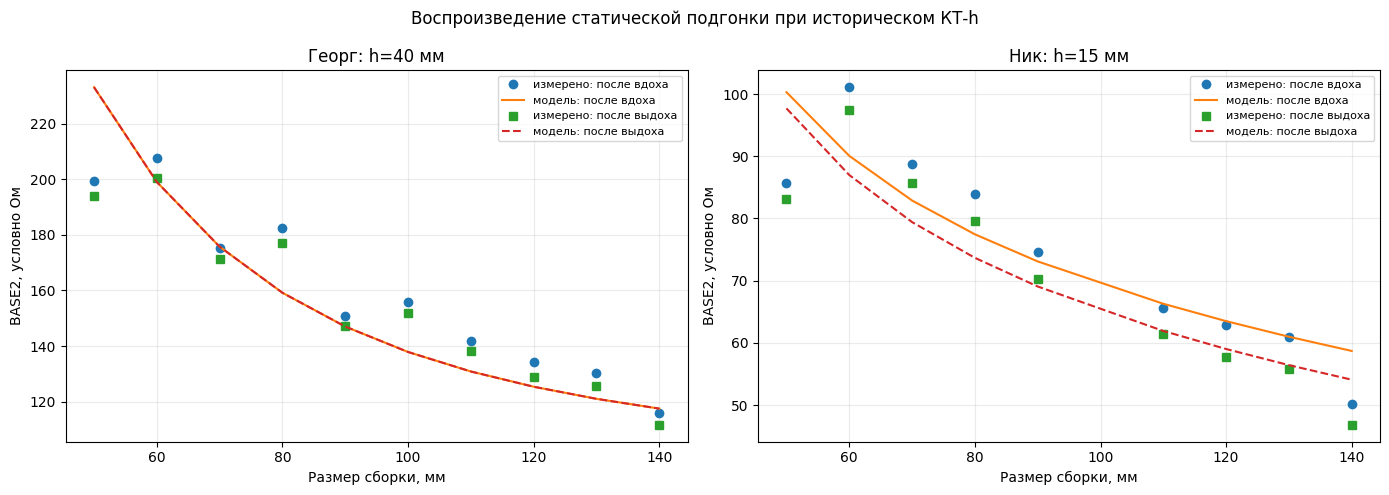

**Результат воспроизведения.** Расчёт при фиксированных исторических значениях $h$ выполнен и сохранён во внешний исследовательский артефакт. Если параметр $\rho_2$ достигает верхней границы, это означает, что данные не определяют его внутри принятого диапазона; значение границы не следует трактовать как свойство лёгкого.

Внешний результат: 33.01_historical_ct_reproduction.provisional.json


In [5]:
if not HISTORICAL_CT_REPRO_MODE:
    print(
        "33.01 historical_CT_reproduction: "
        "set KALMYKOV_RUN_HISTORICAL_CT_REPRO=1 to run"
    )
else:
    import pandas as pd
    import matplotlib.pyplot as plt
    from IPython.display import Markdown, display

    config_value = os.environ.get(CONFIG_ENV)
    if not config_value:
        raise RuntimeError(f"Перед запуском задайте {CONFIG_ENV}")
    config_path = Path(config_value).expanduser().resolve()
    config = json.loads(config_path.read_text(encoding="utf-8"))
    derived_root = Path(config["derived_root"]).expanduser().resolve()
    historical_inputs, historical_provenance = load_historical_ct_inputs(config)
    legacy_params_dir = Path(config["legacy_params_dir"]).expanduser().resolve()
    legacy_static_reference = json.loads(
        (legacy_params_dir / "static.json").read_text(encoding="utf-8")
    )
    legacy_ct_reference = json.loads(
        (legacy_params_dir / "ct.json").read_text(encoding="utf-8")
    )

    historical_results = {}
    table_rows = []
    for subject_id, item in historical_inputs.items():
        rows = sorted(item["rows"], key=lambda row: row["size_mm"])
        sizes_mm = np.asarray([row["size_mm"] for row in rows], dtype=int)
        z_in = np.asarray([row["z_inhale_ohm"] for row in rows], dtype=float)
        z_ex = np.asarray([row["z_exhale_ohm"] for row in rows], dtype=float)
        fit = fit_static_historical(sizes_mm / 1000.0, z_in, z_ex, item["h_m"])
        legacy_label = item["legacy_subject_label"]
        reference = legacy_static_reference[legacy_label]
        reproduced = np.asarray([
            fit["rho1_ohm_m"], fit["rho2_inhale_ohm_m"],
            fit["rho2_exhale_ohm_m"], item["h_m"],
        ])
        expected = np.asarray([
            reference["rho1"], reference["rho2_in"],
            reference["rho2_ex"], reference["h"],
        ])
        regression_diff = float(np.max(np.abs(reproduced - expected)))
        if regression_diff > 1.0e-6:
            raise RuntimeError(f"Расхождение со старым static.json: {subject_id}")
        legacy_ct_rho2 = float(legacy_ct_reference[legacy_label]["rho2_ct"])
        historical_results[subject_id] = {
            "report_label": item["report_label"],
            "h_m": item["h_m"],
            "h_source": "legacy_sidecar_value_described_as_manual_CT_Inobitec",
            "h_validation_status": "not_revalidated_against_CT_masks_or_montage",
            "legacy_ct_rho2_ohm_m": legacy_ct_rho2,
            "legacy_ct_rho2_status": "historical_CT_HU_conversion_not_revalidated",
            "sizes_mm": sizes_mm.tolist(),
            "z_inhale_ohm": z_in.tolist(),
            "z_exhale_ohm": z_ex.tolist(),
            "estimate": {
                key: value for key, value in fit.items()
                if key not in {
                    "predicted_ohm", "residual_ohm",
                    "active_lower_bounds", "active_upper_bounds",
                }
            },
            "predicted_ohm": fit["predicted_ohm"].tolist(),
            "residual_ohm": fit["residual_ohm"].tolist(),
            "active_lower_bounds": fit["active_lower_bounds"].tolist(),
            "active_upper_bounds": fit["active_upper_bounds"].tolist(),
            "legacy_static_regression_max_abs_diff": regression_diff,
        }
        table_rows.append({
            "Доброволец": item["report_label"],
            "h, мм": 1000.0 * item["h_m"],
            "ρ1, Ом·м": fit["rho1_ohm_m"],
            "ρ2 после вдоха, Ом·м": fit["rho2_inhale_ohm_m"],
            "ρ2 после выдоха, Ом·м": fit["rho2_exhale_ohm_m"],
            "ρ2 из старого КТ/HU, Ом·м": legacy_ct_rho2,
            "RMS, Ом": fit["rms_ohm"],
            "Достигнута граница": "да" if fit["parameter_bound_hit"] else "нет",
            "Макс. |Δ| со старым static.json": regression_diff,
        })

    artifact = {
        "schema_version": 1,
        "analysis": "33.01_historical_static_two_layer_with_ct_h",
        "algorithm_version": HISTORICAL_CT_ALGORITHM_VERSION,
        "status": HISTORICAL_CT_STATUS,
        "strict_pipeline_authorized": False,
        "experiment": 2,
        "config_sha256": sha256_file(config_path),
        "h_provenance": {
            "kind": "manual_values_preserved_in_legacy_sidecars",
            "project_claim": "derived_from_manual_CT_Inobitec_segmentation",
            "independent_reproduction_from_CT": False,
        },
        "reproduction_check": {
            "reference": "legacy_params_dir/static.json",
            "absolute_tolerance": 1.0e-6,
            "passed": True,
        },
        "base2_calibration_scenario": {
            "gain": 1.0,
            "offset_ohm": 0.0,
            "sign": 1,
            "status": "historical_as_is_not_calibrated",
        },
        "parameter_bounds_ohm_m": {
            "lower": HISTORICAL_LOWER.tolist(),
            "upper": HISTORICAL_UPPER.tolist(),
        },
        "assumptions": [
            "legacy_h_values_are_used_as_fixed_effective_thickness",
            "h_is_equal_for_both_breathing_states",
            "sequential_size_recordings_are_comparable",
            "rho1_is_equal_between_breath_holds",
            "BASE2_is_used_as_ohm_with_gain1_offset0_sign_plus",
            "flat_two_layer_half_space_is_applicable",
        ],
        "limitations": [
            "h_was_not_recomputed_from_CT_masks_or_STL",
            "measurement_location_and_reduction_rule_for_h_are_not_reconstructed",
            "BASE2_calibration_is_not_validated",
            "within_and_between_record_uncertainty_is_not_propagated",
            "parameter_bound_hit_means_non_identifiability_within_selected_bounds",
        ],
        "provenance": historical_provenance,
        "subjects": historical_results,
    }
    output_dir = derived_root / "exp02" / "exploratory"
    output_dir.mkdir(parents=True, exist_ok=True)
    output_path = output_dir / "33.01_historical_ct_reproduction.provisional.json"
    temporary_path = output_path.with_suffix(output_path.suffix + ".tmp")
    temporary_path.write_text(
        json.dumps(artifact, ensure_ascii=False, indent=2) + "\n",
        encoding="utf-8",
    )
    temporary_path.replace(output_path)

    display(pd.DataFrame(table_rows).round(4))
    fig, axes = plt.subplots(1, len(historical_results), figsize=(14, 5), squeeze=False)
    for axis, (subject_id, result) in zip(axes[0], sorted(historical_results.items())):
        sizes = np.asarray(result["sizes_mm"], dtype=float)
        predicted = np.asarray(result["predicted_ohm"], dtype=float).reshape(-1, 2)
        axis.plot(sizes, result["z_inhale_ohm"], "o", label="измерено: после вдоха")
        axis.plot(sizes, predicted[:, 0], "-", label="модель: после вдоха")
        axis.plot(sizes, result["z_exhale_ohm"], "s", label="измерено: после выдоха")
        axis.plot(sizes, predicted[:, 1], "--", label="модель: после выдоха")
        axis.set_title(f"{result['report_label']}: h={1000*result['h_m']:.0f} мм")
        axis.set_xlabel("Размер сборки, мм")
        axis.set_ylabel("BASE2, условно Ом")
        axis.grid(alpha=0.25)
        axis.legend(fontsize=8)
    fig.suptitle("Воспроизведение статической подгонки при историческом КТ-h")
    fig.tight_layout()
    plt.show()

    display(Markdown(
        "**Результат воспроизведения.** Расчёт при фиксированных исторических "
        "значениях $h$ выполнен и сохранён во внешний исследовательский артефакт. "
        "Если параметр $\\rho_2$ достигает верхней границы, это означает, что "
        "данные не определяют его внутри принятого диапазона; значение границы "
        "не следует трактовать как свойство лёгкого."
    ))
    print("Внешний результат:", output_path.name)


## Интерпретация и ограничения

Синтетическая проверка подтверждает только соответствие кода заданной модели.
Реальный результат остаётся условным по калибровке, $h$, сопоставимости
последовательных записей и применимости плоской двуслойной геометрии. Большая
невязка или полный ранг Якобиана сами по себе не определяют причину расхождения
и не являются валидацией параметров ткани. Профили, исключение размеров и
обусловленность рассматриваются отдельно в `33.02`.
